In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-colorblind')
from scipy.stats import *

In [3]:
bmi_gwas = pd.read_table("/oak/stanford/groups/mrivas/ukbb24983/cnv/gwas/9796/24611/white_british/ukb24983_v2.INI21001.cnv.PHENO1.glm.linear", 
                         header=0)
bmi_gwas.rename_axis({"#CHROM":"CHR", "ID":"SNP"}, axis=1, inplace=True)
bmi_gwas.dropna(inplace=True)
bmi_gwas.tail()

,CHR,POS,SNP,REF,ALT,A1,TEST,OBS_CT,BETA,SE,T_STAT,P
5372,22,49872774,22:49837653-49907896_-,N,+,+,ADD,332246,0.011014,0.095328,0.115541,0.908016
5373,22,49873896,22:49839897-49907896_-,N,+,+,ADD,332246,-0.092162,0.134803,-0.683679,0.494179
5374,22,49874383,22:49840871-49907896_-,N,+,+,ADD,332246,0.077465,0.043194,1.793420,0.072906
5375,22,49874837,22:49840871-49908804_-,N,+,+,ADD,332246,0.041014,0.154703,0.265117,0.790920
5376,22,49875264,22:49840871-49909658_-,N,+,+,ADD,332246,0.356431,0.187196,1.904050,0.056904


In [8]:
bmi_burden = pd.read_table("/oak/stanford/groups/mrivas/ukbb24983/cnv/gene_burden_test/9796/24611/white_british/ukb24983_v2.INI21001.cnv-burden.PHENO1.glm.linear", 
                           header=0)
bmi_burden.rename_axis({"#CHROM":"CHR", "ID":"GENE"}, axis=1, inplace=True)
bmi_burden.dropna(inplace=True)
bmi_burden.tail()

,CHR,POS,GENE,REF,ALT,A1,TEST,OBS_CT,BETA,SE,T_STAT,P
23593,22,51063891,ARSA,N,+,+,ADD,332486,1.585440,0.909142,1.743880,0.081180
23594,22,51142354,SHANK3,N,+,+,ADD,332486,-0.168162,0.324247,-0.518623,0.604024
23595,22,51180189,ACR,N,+,+,ADD,332486,-0.410771,0.668971,-0.614035,0.539193
23596,22,51214003,RABL2B,N,+,+,ADD,332486,0.493535,1.262720,0.390849,0.695909
23597,22,51216789,RPL23AP82,N,+,+,ADD,332486,0.493535,1.262720,0.390849,0.695909


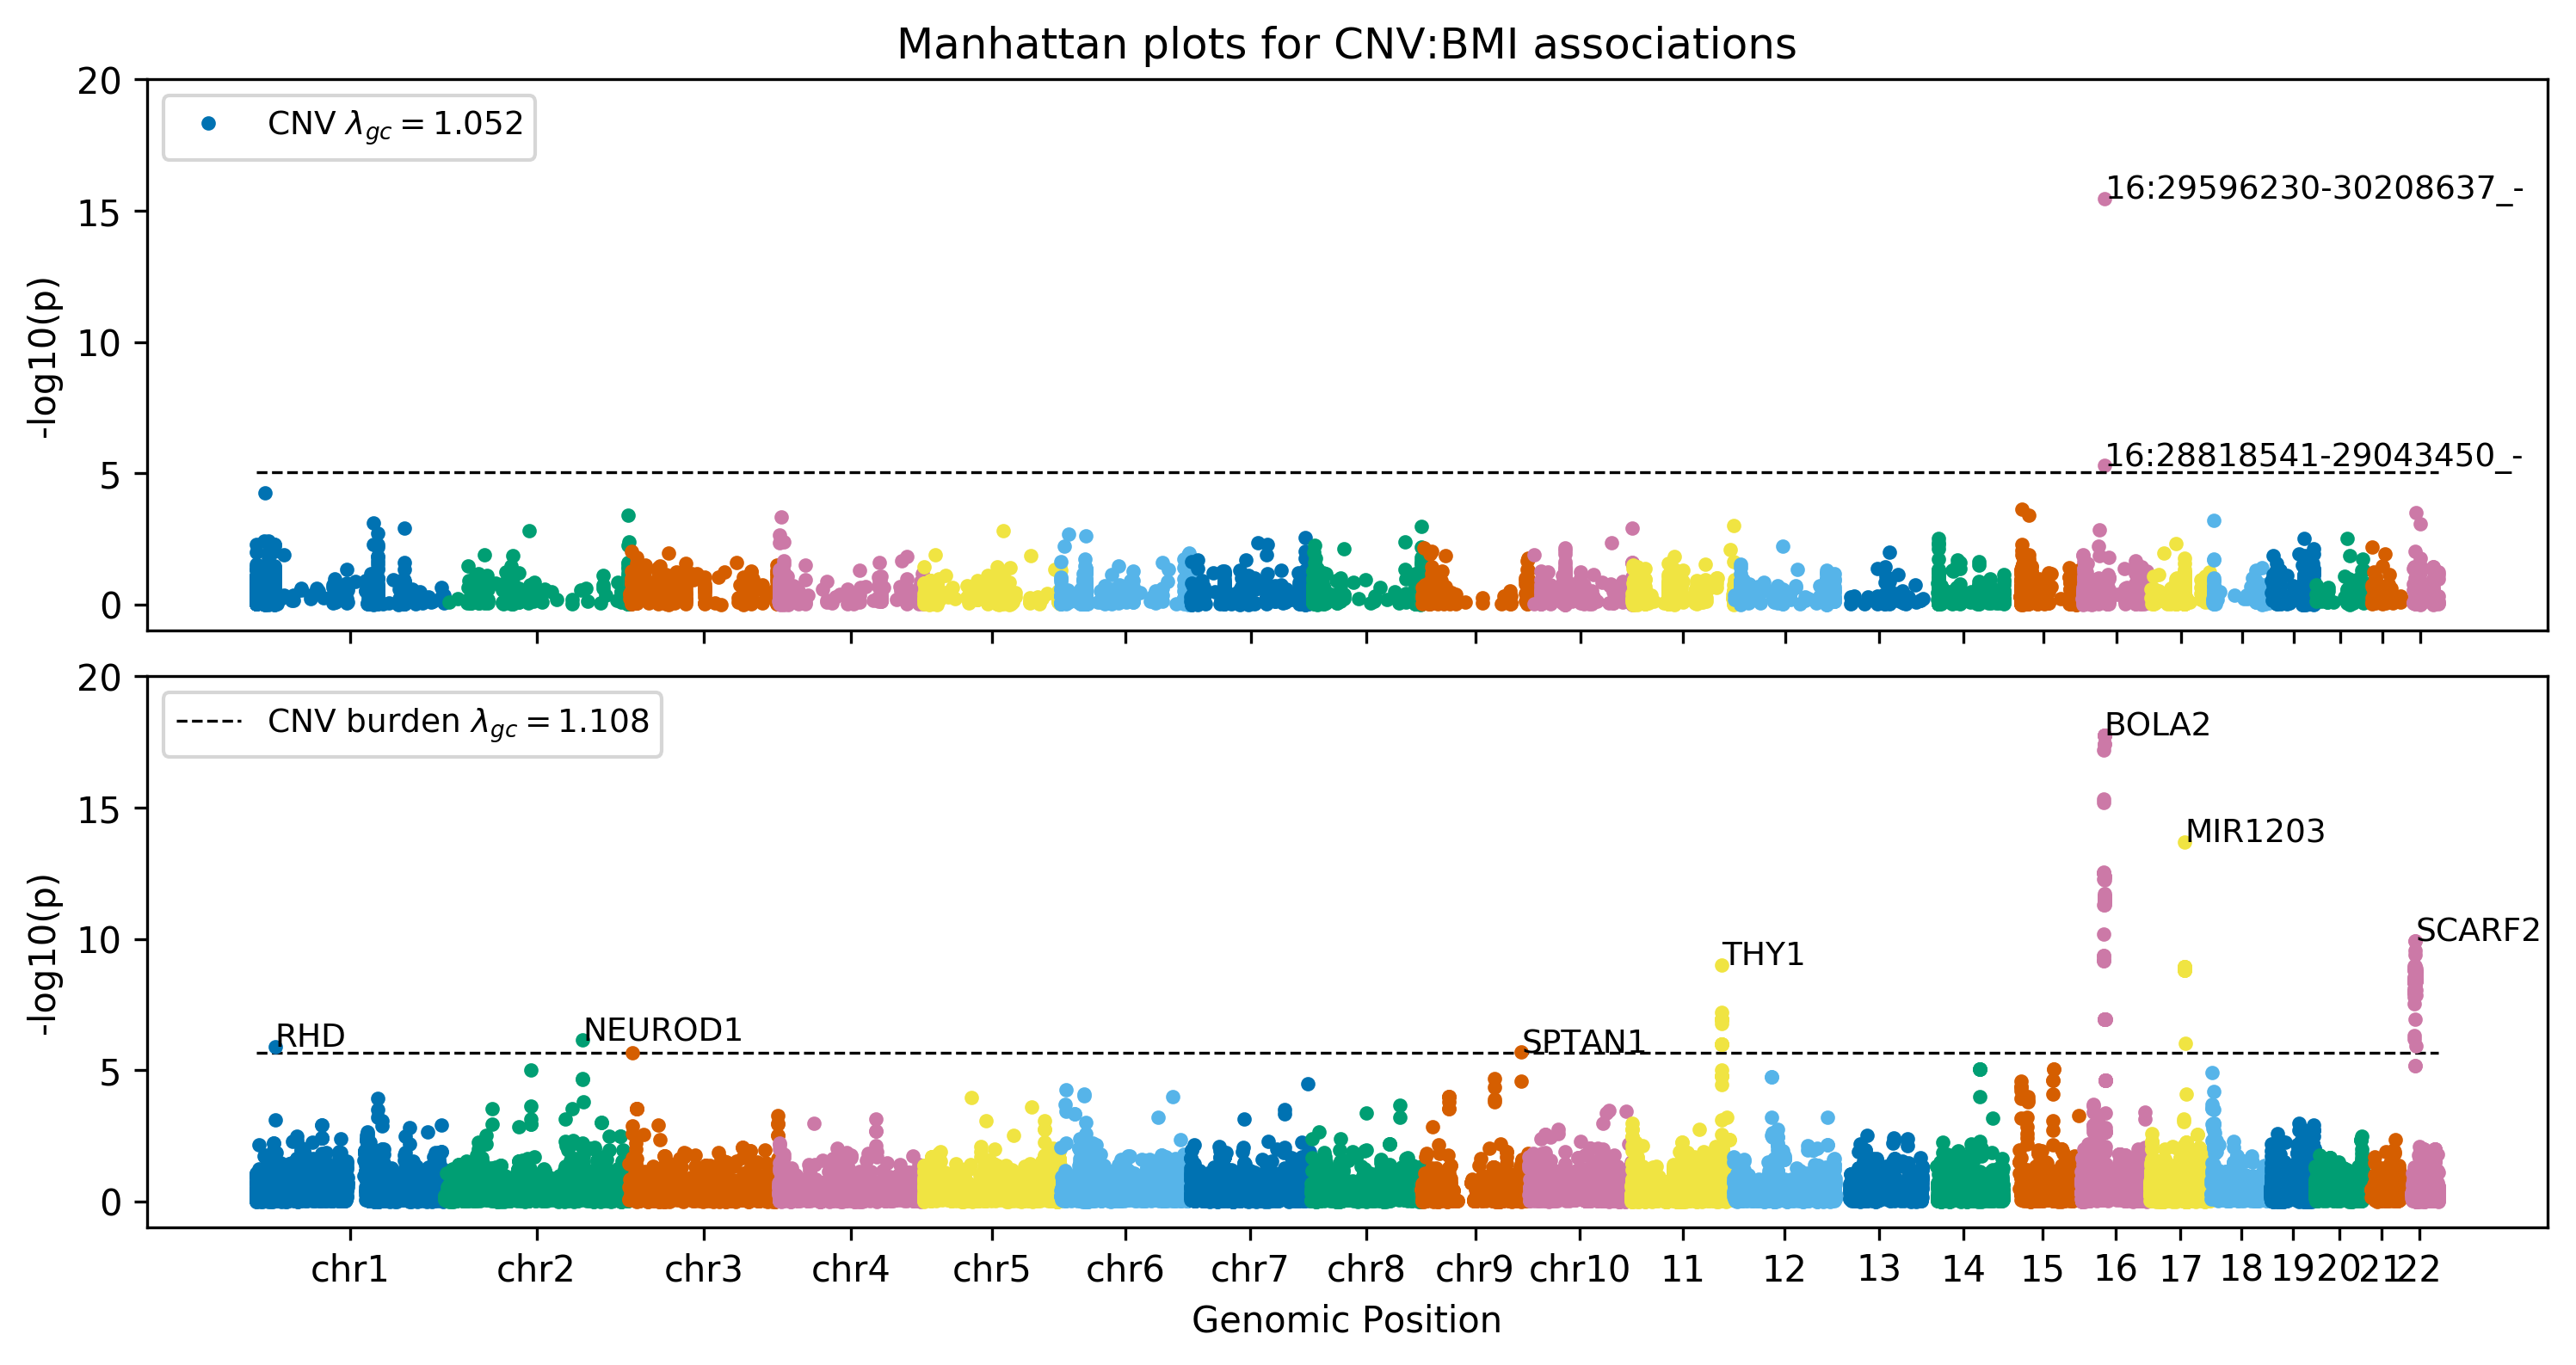

In [18]:
fig  = plt.figure(figsize=(12,11), dpi=300)
grid = plt.GridSpec(11,12,hspace=0.3)

# use this for manhattan plot
chrsize = {'1': 249250621,
           '2': 243199373,
           '3': 198022430,
           '4': 191154276,
           '5': 180915260,
           '6': 171115067,
           '7': 159138663,
           '23': 155270560, # X
           '8': 146364022,
           '9': 141213431,
           '10':135534747,
           '11':135006516,
           '12':133851895,
           '13':115169878,
           '14':107349540,
           '15':102531392,
           '16':90354753,
           '17':81195210,
           '18':78077248,
           '20':63025520,
           '24': 59373566, # Y
           '19':59128983,
           '22':51304566,
           '21':48129895}

#######################
# A: Traditional GWAS #
#######################
fig.add_subplot(grid[:3,:12])

chrlentot = np.cumsum([0]+[chrsize[str(i)] for i in range(1,25) ])
chrbase = {str(c):chrlentot[i] for i,c in enumerate(list(range(1,23)) + ['X','Y'])}

# plot
bmi_gwas['X'] = bmi_gwas['CHR'].apply(lambda i: chrbase[str(i)]) + bmi_gwas['POS']
for c in range(1,23):
    plt.plot(bmi_gwas.loc[bmi_gwas['CHR'] == c, 'X'],
             bmi_gwas.loc[bmi_gwas['CHR'] == c, 'P'].apply(lambda x:-np.log10(x)), '.')

# add significance line
p_star = 0.05/bmi_gwas.shape[0]
mlp_star = -np.log10(p_star)
plt.plot([bmi_gwas['X'].min(), bmi_gwas['X'].max()], [mlp_star, mlp_star], 
         'k--', linewidth=0.8)

# annotate significant variants
for [n,x,p] in bmi_gwas[bmi_gwas['P'] < p_star].loc[:,['SNP','X','P']].values.tolist():
    plt.annotate(n, [x, -np.log10(p)], fontsize=9)

# labels
plt.title('Manhattan plots for CNV:BMI associations')
plt.xticks([chrlentot[c] + (chrlentot[c+1]-chrlentot[c])/2 for c in range(22)], ['' for _ in range(22)])
plt.legend([''.join(['CNV ', '$\lambda_{gc}=$',
                     '{:.3f}'.format(np.median(chi2.ppf(1-bmi_gwas['P'].values, 1))/chi2.ppf(0.5,1))])],
           loc=2, fontsize=9)
plt.ylim((-1,20))
plt.ylabel('-log10(p)')

##################
# B: Burden Test #
##################

fig.add_subplot(grid[3:6,:12])

# compute x-positions for plot
bmi_burden['X'] = bmi_burden['CHR'].apply(lambda i: chrbase[str(i)]) + bmi_burden['POS']

# add significance line
p_star = 0.05/bmi_burden.shape[0]
mlp_star = -np.log10(p_star)
plt.plot([bmi_burden['X'].min(), bmi_burden['X'].max()], [mlp_star, mlp_star], 
         'k--', linewidth=0.8)

# plot the points
for c in range(1,23):
    plt.plot(bmi_burden.loc[bmi_burden['CHR'] == c, 'X'],
             bmi_burden.loc[bmi_burden['CHR'] == c, 'P'].apply(lambda x:-np.log10(x)), '.')
    # add annotation for max point in each chromosome
    #if bmi_burden.loc[bmi_burden['CHR'] == c, 'P'].min() < p_star:
    #    info = bmi_burden.iloc[bmi_burden.loc[bmi_burden['CHR'] == c,'P'].idxmin(),:]
    #    plt.annotate(info['GENE'], [info['X'], -np.log10(info['P'])], fontsize=9)

# annotate significant points (one per chrom)
chr_seen = []
for [c,n,x,p] in bmi_burden[bmi_burden['P'] < p_star].loc[:,['CHR','GENE','X','P']].sort_values('P').values.tolist():
    if c not in chr_seen:
        plt.annotate(n, [x, -np.log10(p)], fontsize=9)
        chr_seen.append(c)

# labels
plt.xlabel('Genomic Position')
plt.xticks([chrlentot[c] + (chrlentot[c+1]-chrlentot[c])/2 for c in range(22)], 
           ['chr{}'.format(c+1) if c < 10 else str(c+1) for c in range(22)])
plt.legend([''.join(['CNV burden ', '$\lambda_{gc}=$',
                     '{:.3f}'.format(np.median(chi2.ppf(1-bmi_burden['P'].values, 1))/chi2.ppf(0.5,1))])],
           loc=2, fontsize=9)
plt.ylim((-1,20))
plt.ylabel('-log10(p)')

"""##################
# C: QQ for GWAS #
##################
ax = fig.add_subplot(grid[7:,8:])

probplot(-np.log10(bmi_gwas['P'].values), dist=expon, plot=ax)
plt.legend(['$\lambda_{gc}=$'+'{:.3f}'.format(np.median(chi2.ppf(1-bmi_gwas['P'].values, 1))/chi2.ppf(0.5,1)),
            'Null distribution'])
plt.title('QQ for BMI CNV GWAS')
plt.ylabel('Observed -log10(p)')
plt.xlabel('Expected -log10(p)')

#################
# D: Locus Zoom #
#################
ax = fig.add_subplot(grid[7:,:7])

# zoom in this region
c16q112 = bmi_burden.query('(CHR == "16") & (BP1 < 31208637) & (BP2 > 28418541)')
for i in range(c16q112.shape[0]):
    plt.plot(c16q112.iloc[i,:].loc[['BP1','BP2']].values.tolist(), 
             [-np.log10(c16q112.iloc[i,:].loc['P']) for _ in range(2)], '-')

# add significance line
p_star = 0.05/bmi_burden.shape[0]
mlp_star = -np.log10(p_star)
plt.plot([c16q112[['BP1', 'BP2']].min().min(), c16q112[['BP1', 'BP2']].max().max()], 
         [mlp_star, mlp_star], 'k--', linewidth=0.8)

# annotate significant variants
for [n,bp1,bp2,p] in c16q112[['GENE','BP1', 'BP2','P']].values.tolist():
    if n in ['BOLA2B', 'SPN', 'CORO1A', 'QPRT', 'ASPHD1', 'INO80E', 'ZG16', 'KIF22',
             'NPIPB9', 'NUPR1', 'TUFM', 'LAT', 'EIF3C', 'SH2B1', 'ZNF688']:
        plt.annotate(n, [int(np.mean((bp1,bp2))), -np.log10(p)], fontsize=6)

# add CNV lines
for cnv in ['16:28818541-29043450_del', '16:29596230-30208637_del']:
    bps = list(map(int, cnv.split(':')[1].split('_')[0].split('-')))
    plt.plot(bps, [mlp_star, mlp_star], 'k-', linewidth=5)
    plt.annotate(cnv, [bps[0], mlp_star+0.5], fontsize=6)

# add other GWAS hits
hits = '''ATXN2L / TUFM	16	28837347	+0.029	4E-29	rs12325113
RPS15AP33	16	28814284	+	8E-10	rs2008514
SH2B1 / ATP2A1	16	28878165	+0.031	2E-31	rs3888190
INO80E	16	30004016	+0.0201	2E-9	rs4787491
SH2B1	16	28862077	+	2E-9	rs4788102
IL27 / NUPR1	16	28527319	+0.023	1E-15	rs62034325
TUFM	16	28846324	+0.0197	4E-8	rs7187776
TMEM219	16	29956694	+0.019	6E-11	rs7204797
SH2B1 / ATP2A1	16	28874338	+0.15	2E-20	rs7359397
SH2B1	16	28871920	+3.63	3E-10	rs7498665'''

plt.plot([int(hit.split('\t')[2]) for hit in hits.split('\n')],
         [-np.log10(float(hit.split('\t')[-2])) for hit in hits.split('\n')], 'rd', markersize=2)
for hit in hits.split('\n'):
    info = hit.split('\t')
    plt.annotate(info[-1], [int(info[2]), -np.log10(float(info[-2]))], fontsize=6)
    

plt.title('$\mathit{16p11.2}$ Locus')
plt.xlabel('Chromosome 16')
plt.ylabel('-log10(p)')
ticks = [int(i) for i in np.linspace(28500000, 30500000, 5)]
plt.xticks(ticks, list(map(str,ticks)))"""

# done
plt.show()

In [10]:
bmi_gwas.query('P < 5e-6').head()

,CHR,POS,SNP,REF,ALT,A1,TEST,OBS_CT,BETA,SE,T_STAT,P,X
4298,16,29902433,16:29596230-30208637_-,N,+,+,ADD,332246,1.34705,0.165077,8.16016,3.357230e-16,2439719544


In [11]:
bmi_burden.query('CHR == "16" & P < 1e-10').sort_values('POS')

,CHR,POS,GENE,REF,ALT,A1,TEST,OBS_CT,BETA,SE,T_STAT,P,X
18005,16,29624730,SLC7A5P1,N,+,+,ADD,332486,2.81809,0.431316,6.53371,6.425040e-11,2439441841
18006,16,29678046,SPN,N,+,+,ADD,332486,3.11856,0.361361,8.63004,6.159260e-18,2439495157
18007,16,29699877,QPRT,N,+,+,ADD,332486,2.86669,0.353202,8.11630,4.822490e-16,2439516988
18008,16,29755562,C16orf54,N,+,+,ADD,332486,2.76456,0.341936,8.08502,6.235800e-16,2439572673
18009,16,29791264,ZG16,N,+,+,ADD,332486,2.21996,0.321645,6.90189,5.140530e-12,2439608375
18015,16,29872142,CDIPT,N,+,+,ADD,332486,2.48664,0.341047,7.29118,3.079260e-13,2439689253
18016,16,29877188,CDIPT-AS1,N,+,+,ADD,332486,2.48664,0.341047,7.29118,3.079260e-13,2439694299
18017,16,29896532,SEZ6L2,N,+,+,ADD,332486,2.48664,0.341047,7.29118,3.079260e-13,2439713643
18018,16,29914761,ASPHD1,N,+,+,ADD,332486,2.48223,0.340163,7.29719,2.944890e-13,2439731872
18019,16,29927604,KCTD13,N,+,+,ADD,332486,2.45088,0.339285,7.22366,5.071300e-13,2439744715


In [12]:
bmi_burden.query('CHR == "16" & 28200000 < POS & POS < 29000000').sort_values('P')

,CHR,POS,GENE,REF,ALT,A1,TEST,OBS_CT,BETA,SE,T_STAT,P,X
17991,16,28841463,ATXN2L,N,+,+,ADD,332486,0.852843,0.406645,2.097270,0.035970,2438658574
17993,16,28855730,TUFM,N,+,+,ADD,332486,0.843466,0.406647,2.074200,0.038062,2438672841
18002,16,28999125,LAT,N,+,+,ADD,332486,0.833732,0.408158,2.042670,0.041086,2438816236
17992,16,28855283,MIR4721,N,+,+,ADD,332486,0.815937,0.408161,1.999060,0.045603,2438672394
18001,16,28990982,SPNS1,N,+,+,ADD,332486,0.795793,0.403667,1.971410,0.048678,2438808093
17995,16,28890759,LOC100289092,N,+,+,ADD,332486,0.719725,0.399321,1.802370,0.071488,2438707870
17999,16,28969942,MIR4517,N,+,+,ADD,332486,0.710571,0.399323,1.779440,0.075168,2438787053
17994,16,28880305,SH2B1,N,+,+,ADD,332486,0.692948,0.396505,1.747640,0.080527,2438697416
18000,16,28970042,NFATC2IP,N,+,+,ADD,332486,0.664140,0.397904,1.669100,0.095099,2438787153
17996,16,28902819,ATP2A1,N,+,+,ADD,332486,0.623343,0.395114,1.577630,0.114652,2438719930
